In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
import torchvision
import torch.nn as nn 
from torch.utils.data import DataLoader,TensorDataset
import torch.optim as optim
from sklearn.model_selection import train_test_split


In [3]:
train_dataset = torchvision.datasets.KMNIST(
    root="./data",
    train=True,
    download=True
)
test_dataset = torchvision.datasets.KMNIST(
    root="./data",
    train=False,
    download=True
)
class_names = ['o', 'ki', 'su', 'tsu', 'na', 'ha', 'ma', 'ya', 're', 'wo']

100%|██████████| 18.2M/18.2M [00:12<00:00, 1.43MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 279kB/s]
100%|██████████| 3.04M/3.04M [00:01<00:00, 1.76MB/s]
100%|██████████| 5.12k/5.12k [00:00<00:00, 12.9MB/s]


In [4]:
print(f"Train Dataset Size: {len(train_dataset)}")
print(f"Test Dataset Size: {len(test_dataset)}")

Train Dataset Size: 60000
Test Dataset Size: 10000


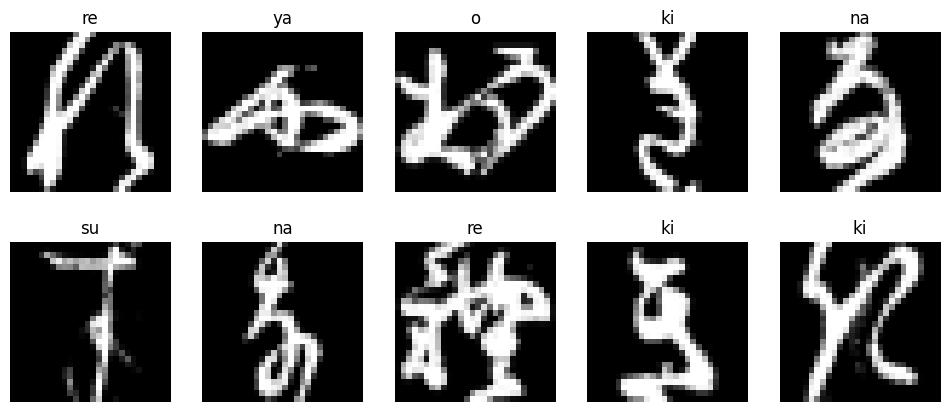

In [5]:
train_images_all = train_dataset.data.numpy()
train_labels_all = train_dataset.targets.numpy()

train_labels_text = [class_names[i] for i in train_labels_all]

test_images_all = test_dataset.data.numpy()
test_labels_all = test_dataset.targets.numpy()
fig,axes = plt.subplots(2,5,figsize=(12,5))

axes = axes.flatten()
for i in range(10):
    axes[i].imshow(train_images_all[i],cmap="gray")
    axes[i].axis("off")
    axes[i].set_title(train_labels_text[i])

plt.show()

In [8]:
X_np = train_images_all
y_np = train_labels_all

X_test_np = test_images_all
y_test_np = test_labels_all

# normalization
def MinMax (target):
    x_min = target.min()
    x_max = target.max()
    x_scaled = (target-x_min)/(x_max - x_min)
    return x_scaled
X_np = MinMax(X_np)

X_train_np , X_val_np,y_train_np,y_val_np = train_test_split(
    X_np,
    y_np,
    random_state=42,
    test_size=0.20
)
X_train_tensor = torch.tensor(X_train_np,dtype=torch.float32)
X_val_tensor = torch.tensor(X_val_np , dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_np, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train_np, dtype=torch.long)
y_test_tensor = torch.tensor(y_test_np, dtype=torch.long)
y_val_tensor = torch.tensor(y_val_np, dtype= torch.long)

# data set
train_tensor_dataset = TensorDataset(X_train_tensor,y_train_tensor) 
test_tensor_dataset = TensorDataset(X_test_tensor,y_test_tensor)
val_tensor_dataset = TensorDataset(X_val_tensor,y_val_tensor)
# data loader
batch_size=32

train_data_loader = DataLoader(train_tensor_dataset,shuffle=True, batch_size=batch_size)
test_data_loader = DataLoader ( test_tensor_dataset,shuffle=True,batch_size=batch_size)
val_data_loader = DataLoader(val_tensor_dataset,shuffle=True,batch_size=batch_size)



In [ ]:
class TranslateClassifier (nn.Module):
    def __init__(self,num_size , class_num):
        super().__init__()
        self.network = nn.Sequential(
            nn.Flatten(),
            nn.ReLU()
        )
    def forward( self,features ):
        output = self.network(features)
        return output
model = TranslateClassifier(num_size=28*28,class_num=10)

criterion = nn.CrossEntropyLoss()
learning_rate=0.001
optimizer = optim.Adam(model.parameters(),lr=learning_rate)
model
 

TranslateClassifier(
  (network): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): ReLU()
  )
)